# 01. Introduction to RAG Evaluation

You can't ship what you can't measure. This notebook builds the cheap, deterministic half of RAG evaluation from scratch: **precision@k**, **recall@k**, and **mean reciprocal rank**, computed on a worked example small enough to verify by hand, then on module 01's 20-doc Pinecone corpus with the 20-question golden eval set this module ships. NB2 picks up the expensive, stochastic half (LLM-as-judge metrics via RAGAS).

The first thing to know: **retrieval quality and generation quality are separable**. Retrieval quality asks "did the right doc come back?" and you can measure it with set arithmetic and ranks. Generation quality asks "did the LLM use the doc faithfully and answer the question?" and that needs an LLM judge. NB1 covers the first half. NB2 covers the second. The split itself is the lesson: the cheap metrics run on every PR, the expensive ones nightly.

## Part 1: a worked toy example

Before touching any real data, let's build the three metrics on something we can verify by hand. Five questions, five documents (A through E), a hand-drawn relevance map, and one fake retriever's outputs.

Reading this side by side, the answers should be obvious. The point of working through them with code is to make sure our helper functions agree with what the eye sees, so we can trust them on the real corpus in Part 2.

In [1]:
import pandas as pd

toy_relevant = {
    "q1": ["A"],
    "q2": ["B", "D"],
    "q3": ["C"],
    "q4": ["A", "E"],
    "q5": ["B"],
}

toy_retrieved = {
    "q1": ["A", "C", "B"],
    "q2": ["B", "C", "E"],
    "q3": ["D", "C", "A"],
    "q4": ["E", "A", "D"],
    "q5": ["C", "D", "E"],
}

side_by_side = pd.DataFrame({
    "question": list(toy_relevant.keys()),
    "relevant": [", ".join(toy_relevant[q]) for q in toy_relevant],
    "retrieved (top-3)": [", ".join(toy_retrieved[q]) for q in toy_retrieved],
})
side_by_side

,question,relevant,retrieved (top-3)
0,q1,A,"A, C, B"
1,q2,"B, D","B, C, E"
2,q3,C,"D, C, A"
3,q4,"A, E","E, A, D"
4,q5,B,"C, D, E"


### Precision@k

Of the top-k retrieved documents, what fraction are relevant?

$$ \text{precision@k} = \frac{|\text{retrieved}[:k] \cap \text{relevant}|}{k} $$

For q1 with k=3: the top 3 are `[A, C, B]`, the relevant set is `{A}`, the intersection is `{A}`. Precision@3 = 1/3.

For q2 with k=3: top 3 `[B, C, E]`, relevant `{B, D}`, intersection `{B}`. Precision@3 = 1/3.

Let's hand-compute, then verify with the helper.

In [2]:
from helpers import precision_at_k

def hand_precision_at_k(retrieved, relevant, k):
    top_k = retrieved[:k]
    return sum(1 for d in top_k if d in set(relevant)) / k

rows = []
for q in toy_relevant:
    rel = toy_relevant[q]
    ret = toy_retrieved[q]
    p1_hand = hand_precision_at_k(ret, rel, 1)
    p3_hand = hand_precision_at_k(ret, rel, 3)
    p1_help = precision_at_k(ret, rel, 1)
    p3_help = precision_at_k(ret, rel, 3)
    rows.append({
        "question": q,
        "p@1 hand": round(p1_hand, 3),
        "p@1 helper": round(p1_help, 3),
        "p@3 hand": round(p3_hand, 3),
        "p@3 helper": round(p3_help, 3),
    })

pd.DataFrame(rows)

,question,p@1 hand,p@1 helper,p@3 hand,p@3 helper
0,q1,1.0,1.0,0.333,0.333
1,q2,1.0,1.0,0.333,0.333
2,q3,0.0,0.0,0.333,0.333
3,q4,1.0,1.0,0.667,0.667
4,q5,0.0,0.0,0.000,0.000


### Recall@k

Of the relevant documents, what fraction made it into top-k?

$$ \text{recall@k} = \frac{|\text{retrieved}[:k] \cap \text{relevant}|}{|\text{relevant}|} $$

There's a trade-off baked in: precision usually drops as k grows (you add more wrong answers), recall usually rises (you have more chances to catch the right ones). Plotting both for one query makes the trade-off obvious.

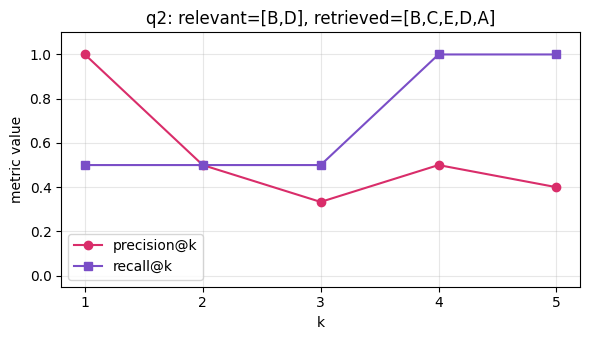

In [3]:
import matplotlib.pyplot as plt
from helpers import recall_at_k

# Use q2: relevant = [B, D], retrieved (extended) = [B, C, E, D, A]
q2_retrieved_long = ["B", "C", "E", "D", "A"]
q2_relevant = toy_relevant["q2"]

ks = list(range(1, 6))
p_vals = [precision_at_k(q2_retrieved_long, q2_relevant, k) for k in ks]
r_vals = [recall_at_k(q2_retrieved_long, q2_relevant, k) for k in ks]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks, p_vals, marker="o", label="precision@k", color="#d92d6a")
ax.plot(ks, r_vals, marker="s", label="recall@k", color="#7a4ec7")
ax.set_xlabel("k")
ax.set_ylabel("metric value")
ax.set_title("q2: relevant=[B,D], retrieved=[B,C,E,D,A]")
ax.set_ylim(-0.05, 1.1)
ax.set_xticks(ks)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Mean reciprocal rank (MRR)

For each query, take 1 divided by the rank of the first relevant document (or 0 if no relevant doc was retrieved), then average across queries.

$$ \text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q} $$

For q1, the relevant doc `A` shows up at rank 1, so RR = 1.0.
For q4, the relevant docs `[A, E]` first appear at rank 1 (`E`), so RR = 1.0.
For q5, the relevant doc `B` doesn't appear in the top 3, so RR = 0.0.

MRR is the right metric when you typically have one right answer per question and you care most about whether it lands at the top. It collapses the whole ranked list into one number per query.

In [4]:
from helpers import mean_reciprocal_rank

def hand_rr(retrieved, relevant):
    relevant_set = set(relevant)
    for rank, doc in enumerate(retrieved, start=1):
        if doc in relevant_set:
            return 1.0 / rank
    return 0.0

per_q = {q: round(hand_rr(toy_retrieved[q], toy_relevant[q]), 3) for q in toy_relevant}
hand_mrr = round(sum(per_q.values()) / len(per_q), 3)

retrieved_lists = [toy_retrieved[q] for q in toy_relevant]
relevant_lists = [toy_relevant[q] for q in toy_relevant]
helper_mrr = round(mean_reciprocal_rank(retrieved_lists, relevant_lists), 3)

print(f"Per-query reciprocal ranks (hand): {per_q}")
print(f"MRR (hand):   {hand_mrr}")
print(f"MRR (helper): {helper_mrr}")

Per-query reciprocal ranks (hand): {'q1': 1.0, 'q2': 1.0, 'q3': 0.5, 'q4': 1.0, 'q5': 0.0}
MRR (hand):   0.7
MRR (helper): 0.7


### What we just built

Three metrics, three formulas, no library beyond pandas and matplotlib. The bigger point: **the cheap metrics are set arithmetic and ranks**. No LLM, no embeddings, no money. They run on every PR.

Now the real corpus.

## Part 2: the real eval set

Module 01's 20-doc Pinecone corpus (paraphrased docs about indexes, vectors, namespaces, performance, inference, and the REST API), plus this module's 20-question golden eval set, each tagged with one of four shapes: `keyword`, `paraphrase`, `synthesis`, `adversarial`. The shape tags are the cheapest analytic win available, and you'll see why in a moment.

In [5]:
from pathlib import Path
from scripts.build_eval_set import build_if_missing

# Build (or load) the golden eval set
eval_path = build_if_missing()
golden = pd.read_parquet(eval_path)

# Load module 01's corpus
corpus_path = Path("../01-intro-to-rag/data/corpus.parquet")
if not corpus_path.exists():
    raise FileNotFoundError(
        f"Module 01 corpus not found at {corpus_path}. "
        "Run `python scripts/build_corpus.py` inside 01-intro-to-rag/ first."
    )
corpus = pd.read_parquet(corpus_path)

print(f"Corpus: {len(corpus)} docs")
print(f"Golden eval set: {len(golden)} questions")
print(f"Shape breakdown: {golden['shape'].value_counts().to_dict()}")
golden.head(3)

Corpus: 20 docs
Golden eval set: 20 questions
Shape breakdown: {'keyword': 6, 'paraphrase': 5, 'synthesis': 5, 'adversarial': 4}


,question_id,question,ground_truth_answer,relevant_doc_ids,shape
0,q01,What does the pool_threads parameter do?,It opens that many parallel HTTP connections s...,[doc_7eaf9d85e4b5],keyword
1,q02,How do I use the $in operator in a metadata fi...,$in matches when the field equals any value in...,[doc_50ae76610fa0],keyword
2,q03,What does pc.has_index(name) return?,True if an index with that name exists in the ...,[doc_42de0361ce4a],keyword


In [6]:
from helpers import build_bm25_index, retrieve

doc_ids = corpus["id"].tolist()
docs = corpus["text"].tolist()
retriever, _ = build_bm25_index(docs)

# Run BM25 on every question, store top-5 retrieved doc_ids
results = []
for _, q in golden.iterrows():
    idxs, scores = retrieve(retriever, q["question"], k=5)
    retrieved_ids = [doc_ids[i] for i in idxs]
    results.append({
        "question_id": q["question_id"],
        "shape": q["shape"],
        "question": q["question"],
        "retrieved_ids": retrieved_ids,
        "relevant_ids": list(q["relevant_doc_ids"]),
    })

results_df = pd.DataFrame(results)
results_df.head(3)[["question_id", "shape", "question"]]

,question_id,shape,question
0,q01,keyword,What does the pool_threads parameter do?
1,q02,keyword,How do I use the $in operator in a metadata fi...
2,q03,keyword,What does pc.has_index(name) return?


In [7]:
# Per-question metrics
per_q_rows = []
for r in results:
    per_q_rows.append({
        "question_id": r["question_id"],
        "shape": r["shape"],
        "p@1": precision_at_k(r["retrieved_ids"], r["relevant_ids"], 1),
        "p@3": precision_at_k(r["retrieved_ids"], r["relevant_ids"], 3),
        "r@5": recall_at_k(r["retrieved_ids"], r["relevant_ids"], 5),
    })
per_q_df = pd.DataFrame(per_q_rows)
per_q_df.round(3)

,question_id,shape,p@1,p@3,r@5
0,q01,keyword,0.0,0.333,1.0
1,q02,keyword,0.0,0.333,1.0
2,q03,keyword,1.0,0.333,1.0
3,q04,keyword,1.0,0.333,1.0
4,q05,keyword,1.0,0.333,1.0
5,q06,keyword,0.0,0.333,1.0
6,q07,paraphrase,1.0,0.333,1.0
7,q08,paraphrase,0.0,0.333,1.0
8,q09,paraphrase,1.0,0.333,1.0
9,q10,paraphrase,1.0,0.333,1.0


In [8]:
# Overall MRR (the helper skips adversarial questions automatically since
# their relevant_ids list is empty)
retrieved_lists = [r["retrieved_ids"] for r in results]
relevant_lists = [r["relevant_ids"] for r in results]
overall_mrr = mean_reciprocal_rank(retrieved_lists, relevant_lists)

print(f"Overall metrics across {len(per_q_df)} questions:")
print(f"  mean p@1: {per_q_df['p@1'].mean():.3f}")
print(f"  mean p@3: {per_q_df['p@3'].mean():.3f}")
print(f"  mean r@5: {per_q_df['r@5'].mean():.3f}")
print(f"  MRR:      {overall_mrr:.3f}  (excludes adversarial)")

Overall metrics across 20 questions:
  mean p@1: 0.450
  mean p@3: 0.317
  mean r@5: 0.890
  MRR:      0.740  (excludes adversarial)


### The shape breakdown

Three numbers and an MRR don't tell you much. The same three numbers broken down by shape tell you everything.

In [9]:
by_shape = per_q_df.groupby("shape")[["p@1", "p@3", "r@5"]].mean().round(3)

# Per-shape MRR (handles adversarial via the helper's empty-relevant skip)
shape_mrr = {}
for shape in golden["shape"].unique():
    mask = [r["shape"] == shape for r in results]
    shape_mrr[shape] = mean_reciprocal_rank(
        [r["retrieved_ids"] for r, m in zip(results, mask) if m],
        [r["relevant_ids"] for r, m in zip(results, mask) if m],
    )

by_shape["MRR"] = pd.Series(shape_mrr).round(3)
by_shape = by_shape.reindex(["keyword", "paraphrase", "synthesis", "adversarial"])
by_shape

,p@1,p@3,r@5,MRR
shape,,,,
keyword,0.5,0.333,1.00,0.694
paraphrase,0.6,0.333,0.90,0.767
synthesis,0.6,0.533,0.66,0.767
adversarial,0.0,0.000,1.00,0.000


### What this tells us (and what surprised me)

A few things worth pointing at honestly:

1. **BM25 doesn't dominate the keyword shape as cleanly as I'd expected.** Mean p@1 on keyword questions is 0.5, not 1.0. The misses are illuminating: `$in` got tokenized away by BM25's stopword/punctuation handling, the question about authentication used the word "authenticate" instead of the doc's "Api-Key", and the question about `pool_threads` got beaten on rank 1 by a "dimension" doc that shared more common-word vocabulary. Recall@5 is 1.0 across all six keyword questions, which means the right doc is *in* the top 5; ranking it first is the harder problem.

2. **Paraphrase shape actually does pretty well.** Mean p@1 = 0.6, recall@5 = 0.9. BM25 catches paraphrases when there's any sub-word overlap (q07 finds "integrated inference" because both the question and the doc contain "embeddings"). It misses cleanly when the vocabulary is truly disjoint (q08's "similarity score" vs the doc's "metric", q11's "push" vs the doc's "upsert"). Module 03 NB3 already demonstrated this; here it's quantified.

3. **Synthesis shape has the worst recall@5 (0.66).** Multi-doc questions need to pull 3-5 relevant docs into top-5; BM25 usually gets one or two but misses the rest. Vector retrieval typically does better here, which is what NB3 will show.

4. **Adversarial p@k is reported as 0.0** because BM25 retrieves *something* for every query (it can't refuse). This isn't a bug, it's the design boundary: retrieval metrics can't tell you whether the system should have answered at all. That's what faithfulness (NB2) is for.

The shape breakdown is the cheapest analytical win available. A single overall p@1 of 0.45 hides four very different stories. Tagging your eval set by question shape, and breaking the metrics down by shape, is the move.

## What's still missing

We measured whether the right doc came back. We didn't measure whether the LLM's *generated answer* actually used it faithfully, or whether the answer was relevant to the question, or whether the system refused gracefully on the adversarial questions. Those questions need an LLM judge.

That's NB2. RAGAS, four metrics, the LLM as the panel, and the stochastic-cost trade that comes with it.

## Recap

| Metric | Formula | Edge case |
|---|---|---|
| **precision@k** | `|retrieved[:k] ∩ relevant| / k` | Empty relevant set: returns 1.0 if `retrieved[:k]` empty else 0.0 |
| **recall@k** | `|retrieved[:k] ∩ relevant| / |relevant|` | Empty relevant set: returns 1.0 (nothing to recall) |
| **MRR** | `mean(1 / rank_of_first_relevant)` | Queries with empty relevant set are skipped from the average |

Three formulas, four shape tags, one corpus. The cheap metrics in CI. The expensive ones in NB2.